In [3]:
import pandas as pd
import os

DATA_ROOT = 'data'
TEST_FILE = 'fix_filenames:big-mpl:f3db2b83a:20260719_012333.jsonl'

def load_df(fname):
    df = pd.read_json(os.path.join(DATA_ROOT, fname), lines=True)
    df.set_index('bench')
    return df

df = load_df(TEST_FILE)
df


,bench,cmd,compilerAbbrev,compileTime,runTime,binarySize,binaryChecksum,hostname,timestamp,commitHash
0,barnes-hut,../../build/bin/mlton -link-opt -s,MLton0,1.918982,30.153724,155175,0d5936c06fd8b67fed4ad0de5c321fdd,big-mpl,2026-07-19 01:24:36,f3db2b83a0af47e67821949e5f77b0bd2d262c22
1,barnes-hut,../../build/bin/mlton $SHARED_FLAGS -pre-flatt...,MLton1,1.932438,30.198158,155175,a1ca4dfc687cebaedc3d07188b42ce41,big-mpl,2026-07-19 01:25:38,f3db2b83a0af47e67821949e5f77b0bd2d262c22
2,boyer,../../build/bin/mlton -link-opt -s,MLton0,1.984499,24.677349,239013,dec246840f93dc63bc9a0d3ad0e5f400,big-mpl,2026-07-19 01:26:54,f3db2b83a0af47e67821949e5f77b0bd2d262c22
3,boyer,../../build/bin/mlton $SHARED_FLAGS -pre-flatt...,MLton1,2.025831,24.715405,239013,c4a40163564fe98bb41cc553d8b07fa7,big-mpl,2026-07-19 01:28:10,f3db2b83a0af47e67821949e5f77b0bd2d262c22
4,checksum,../../build/bin/mlton -link-opt -s,MLton0,1.597920,31.918371,97949,53aa8dd0cfc90e443f069a024a45fdff,big-mpl,2026-07-19 01:29:16,f3db2b83a0af47e67821949e5f77b0bd2d262c22
...,...,...,...,...,...,...,...,...,...,...
85,wc-scanStream,../../build/bin/mlton $SHARED_FLAGS -pre-flatt...,MLton1,1.974608,28.558143,170728,1a52fde22fc0eec5cf8973071782f4dd,big-mpl,2026-07-19 03:16:37,f3db2b83a0af47e67821949e5f77b0bd2d262c22
86,zebra,../../build/bin/mlton -link-opt -s,MLton0,2.011175,21.610103,167003,8bbc7f370367dac270e302e2944a2d0e,big-mpl,2026-07-19 03:17:44,f3db2b83a0af47e67821949e5f77b0bd2d262c22
87,zebra,../../build/bin/mlton $SHARED_FLAGS -pre-flatt...,MLton1,2.013336,21.647672,167003,1c0f6d8b4c604837a6b9d9689dd8ae83,big-mpl,2026-07-19 03:18:50,f3db2b83a0af47e67821949e5f77b0bd2d262c22
88,zern,../../build/bin/mlton -link-opt -s,MLton0,1.691584,35.653205,133032,cf89107ff11074a95ee8075da7ef3684,big-mpl,2026-07-19 03:20:03,f3db2b83a0af47e67821949e5f77b0bd2d262c22


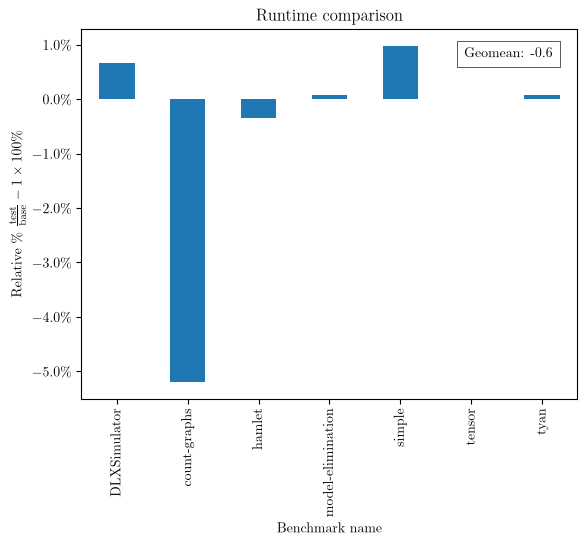

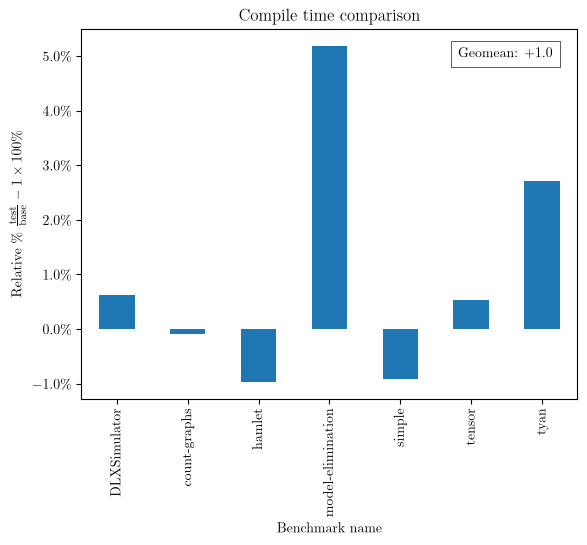

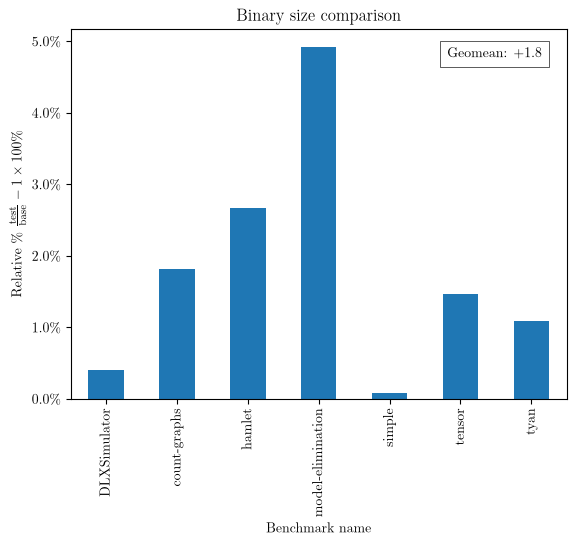

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from dataclasses import dataclass

# Use system latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

def plot_mlton(df, values='runTime', title='', abbrevs=('MLton0', 'MLton1'), 
              identity_col='binarySize'):
    # Remove columns we don't care about
    if identity_col == values:
        filtered = df[['bench', 'compilerAbbrev', values]]
    else:
        filtered = df[['bench', 'compilerAbbrev', values, identity_col]]
    # Remove benchmarks witn identical binaries
    filtered = df[filtered.groupby('bench')[identity_col].transform('nunique') > 1]
    pivot = filtered.pivot(index='bench', columns='compilerAbbrev', values=values)
    # Calculate the ratio (<1 is good, >1 is bad)
    abs_ratio = pivot[abbrevs[1]] / pivot[abbrevs[0]]
    # Convert to relative_pct (<0% is good, >0% is bad)
    pivot['relative_pct'] = (abs_ratio - 1) * 100
    ax = (pivot['relative_pct']).plot(kind='bar')

    # Calculate the absolute geomean (1.0 is neutral)
    abs_geomean = np.exp(np.mean(np.log(abs_ratio.dropna())))
    # Scale to match the metric for relative_pct
    geomean_pct = (abs_geomean - 1) * 100
    # Add a text box
    textstr = f'Geomean: {geomean_pct:+.1f}%'
    props = dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black', linewidth=0.5)
    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    ax.set_title(title)
    ax.set_xlabel('Benchmark name')
    ax.set_ylabel(r'Relative \% $\frac{\mathrm{test}}{\mathrm{base}} - 1 \times 100\%$')
    ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    plt.show()

@dataclass(frozen=True)
class PlotConfig:
    values_column: str
    title: str

configs = [
    PlotConfig(values_column='runTime',
               title='Runtime comparison'),
    PlotConfig(values_column='compileTime',
               title='Compile time comparison'),
    PlotConfig(values_column='binarySize',
               title='Binary size comparison'),
]

for c in configs:
    plot_mlton(df, values=c.values_column, title=c.title)